# 03 - Modeling & Evaluation
## Dataset FAR-Trans: Transparent Investment Intention Analysis

**Penulis:** Naufal Rizki Abyan (23082010235)  
**Program:** Magang Riset - Transparent Investment Intention Analysis  
**Notebook:** 03/05 (Modeling - MK Data Mining)

---

## Tujuan Notebook

Notebook ini melakukan **Modeling** sesuai fase CRISP-DM untuk membangun model klasifikasi yang memprediksi **risk level** investor berdasarkan fitur perilaku transaksi.

1. **Load processed data** — X_train, X_test, y_train, y_test dari `data/processed/`
2. **Baseline model** — Decision Tree sebagai benchmark awal
3. **Advanced models** — Random Forest dan XGBoost dengan hyperparameter tuning
4. **Evaluasi komprehensif** — Accuracy, Precision, Recall, F1-Score (macro & per-class), Confusion Matrix
5. **Analisis feature importance** — Identifikasi fitur paling berpengaruh
6. **Save best model + artefak** — Model, visualisasi, tabel perbandingan untuk laporan

## Target Variable

`riskLevel` — 4 kelas (multi-class classification). Mapping akan di-load dari `LabelEncoder` yang disimpan dari notebook preprocessing.

## Strategi Hyperparameter Tuning

Untuk efisiensi waktu (timeline 1 bulan), grid parameter dibuat fokus pada parameter paling impactful berdasarkan literature (Kuhn & Johnson, 2013; Chen & Guestrin, 2016). Total fitness evaluation berkurang signifikan dari grid eksploratif sambil tetap mencakup region parameter yang paling impactful.

---
## 1. Setup & Load Processed Data

In [7]:
# Setup import path
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import json

# Settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Paths
PROCESSED_DIR = project_root / 'data' / 'processed'
MODEL_DIR = project_root / 'models'
REPORT_DIR = project_root / 'reports'
FIG_DIR = REPORT_DIR / 'figures' / 'modeling'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data dir: {PROCESSED_DIR}")
print(f"Model dir: {MODEL_DIR}")
print(f"Figures dir: {FIG_DIR}")

Project root: C:\All Projects\Transparent Investment Intentions Dashboard
Data dir: C:\All Projects\Transparent Investment Intentions Dashboard\data\processed
Model dir: C:\All Projects\Transparent Investment Intentions Dashboard\models
Figures dir: C:\All Projects\Transparent Investment Intentions Dashboard\reports\figures\modeling


In [10]:
# Load processed data
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').values.ravel()

# Load LabelEncoder dari notebook 02 (Fix #2: dynamic mapping)
le_target = joblib.load(MODEL_DIR / 'label_encoder.pkl')
label_names = list(le_target.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"\nTotal features: {X_train.shape[1]}")
print(f"Target encoding (dari LabelEncoder):")
for i, name in enumerate(label_names):
    print(f"  {i} -> {name}")

print(f"\nTarget distribution (train):")
for cls, name in enumerate(label_names):
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    print(f"  {name}: {count:,} ({pct:.1f}%)")

X_train shape: (10888, 33)
X_test shape:  (2723, 33)
y_train shape: (10888,)
y_test shape:  (2723,)

Total features: 33
Target encoding (dari LabelEncoder):
  0 -> Aggressive
  1 -> Balanced
  2 -> Conservative
  3 -> Income

Target distribution (train):
  Aggressive: 1,232 (11.3%)
  Balanced: 3,609 (33.1%)
  Conservative: 1,543 (14.2%)
  Income: 4,504 (41.4%)


---
## 2. Helper Functions

Fungsi-fungsi utilitas untuk evaluasi model secara konsisten. Setiap fungsi otomatis menyimpan visualisasi ke `reports/figures/modeling/`.

In [11]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, label_names):
    """Evaluasi model secara komprehensif dan return metrics dict."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    metrics = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (macro)': precision_score(y_test, y_test_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_test, y_test_pred, average='macro', zero_division=0),
        'F1-Score (macro)': f1_score(y_test, y_test_pred, average='macro', zero_division=0),
    }
    
    print(f"\n{'='*60}")
    print(f"  {model_name} - Evaluation Results")
    print(f"{'='*60}")
    print(f"  Train Accuracy: {metrics['Train Accuracy']:.4f}")
    print(f"  Test Accuracy:  {metrics['Test Accuracy']:.4f}")
    print(f"  Precision (macro): {metrics['Precision (macro)']:.4f}")
    print(f"  Recall (macro):    {metrics['Recall (macro)']:.4f}")
    print(f"  F1-Score (macro):  {metrics['F1-Score (macro)']:.4f}")
    
    # Overfitting check
    gap = metrics['Train Accuracy'] - metrics['Test Accuracy']
    if gap > 0.05:
        print(f"  [!] Overfitting detected: gap = {gap:.4f}")
    else:
        print(f"  [OK] No significant overfitting: gap = {gap:.4f}")
    
    print(f"\n--- Classification Report ---")
    print(classification_report(y_test, y_test_pred, 
                                target_names=label_names, 
                                digits=4, zero_division=0))
    
    return metrics, y_test_pred


def plot_confusion_matrix(y_test, y_pred, label_names, model_name, save=True):
    """Plot confusion matrix dengan heatmap, save ke disk."""
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_title(f'{model_name} - Confusion Matrix (Counts)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_title(f'{model_name} - Confusion Matrix (Normalized)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    
    if save:
        safe_name = model_name.lower().replace(' ', '_')
        filepath = FIG_DIR / f'cm_{safe_name}.png'
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"  [SAVED] {filepath.name}")
    plt.show()


def plot_feature_importance(model, feature_names, model_name, top_n=15, save=True):
    """Plot top-N feature importance, save ke disk."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    
    ax.barh(range(top_n), importances[indices][::-1], color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in indices][::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{model_name} - Top {top_n} Feature Importance')
    
    plt.tight_layout()
    
    if save:
        safe_name = model_name.lower().replace(' ', '_')
        filepath = FIG_DIR / f'feat_imp_{safe_name}.png'
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"  [SAVED] {filepath.name}")
    plt.show()
    
    print(f"\nTop {top_n} Features:")
    for rank, idx in enumerate(indices, 1):
        print(f"  {rank:2d}. {feature_names[idx]:40s} {importances[idx]:.4f}")

In [12]:
# Setup StratifiedKFold dengan random_state untuk reproducibility (Fix #5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Cross-validation: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"  -> Stratified: proporsi kelas seimbang di setiap fold")
print(f"  -> Shuffled with seed: reproducible & robust")

Cross-validation: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  -> Stratified: proporsi kelas seimbang di setiap fold
  -> Shuffled with seed: reproducible & robust


---
## 3. Model 1: Decision Tree (Baseline)

### Justifikasi
Decision Tree dipilih sebagai **baseline** karena:
- Interpretable dan mudah divisualisasi
- Tidak memerlukan scaling
- Memberikan benchmark awal untuk perbandingan

### Hyperparameter Grid (Reduced)
Grid difokuskan pada parameter paling impactful: `max_depth` (kontrol depth), `min_samples_split` & `min_samples_leaf` (kontrol kompleksitas), serta `class_weight='balanced'` (tetap untuk handle imbalance).

**Total: 16 kombinasi × 5 folds = 80 fits (estimasi <30 detik)**

In [15]:
# Decision Tree - Hyperparameter Tuning (Fix #1: reduced grid)
print("Decision Tree - GridSearchCV (5-fold Stratified CV)")
print("="*60)

dt_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced']  # Selalu balanced karena imbalanced
}

dt_base = DecisionTreeClassifier(random_state=42, criterion='gini')

dt_grid = GridSearchCV(
    dt_base,
    dt_param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

dt_grid.fit(X_train, y_train)

print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best CV F1-macro: {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_

Decision Tree - GridSearchCV (5-fold Stratified CV)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-macro: 0.3742


In [16]:
# Decision Tree - Evaluation
dt_metrics, dt_pred = evaluate_model(
    dt_best, X_train, y_train, X_test, y_test, 
    "Decision Tree", label_names
)


  Decision Tree - Evaluation Results
  Train Accuracy: 0.5064
  Test Accuracy:  0.3849
  Precision (macro): 0.3834
  Recall (macro):    0.4521
  F1-Score (macro):  0.3864
  [!] Overfitting detected: gap = 0.1216

--- Classification Report ---
              precision    recall  f1-score   support

  Aggressive     0.2671    0.5455    0.3586       308
    Balanced     0.4411    0.4186    0.4295       903
Conservative     0.3441    0.6062    0.4390       386
      Income     0.4811    0.2380    0.3185      1126

    accuracy                         0.3849      2723
   macro avg     0.3834    0.4521    0.3864      2723
weighted avg     0.4242    0.3849    0.3769      2723



  [SAVED] cm_decision_tree.png


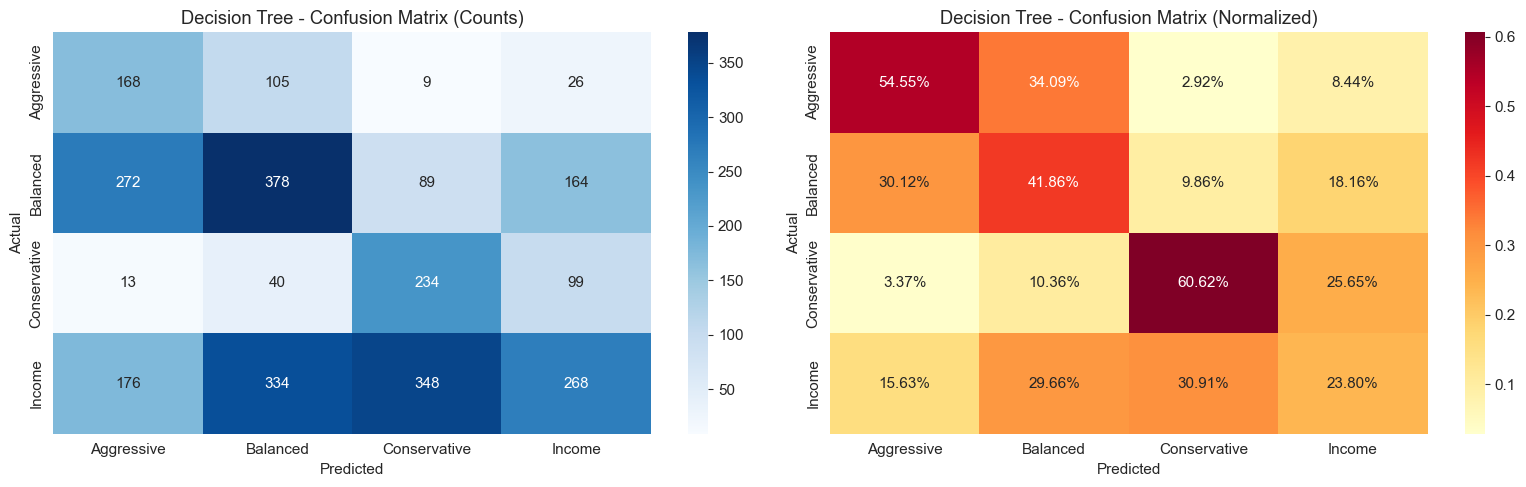

In [17]:
# Decision Tree - Confusion Matrix
plot_confusion_matrix(y_test, dt_pred, label_names, "Decision Tree")

  [SAVED] feat_imp_decision_tree.png


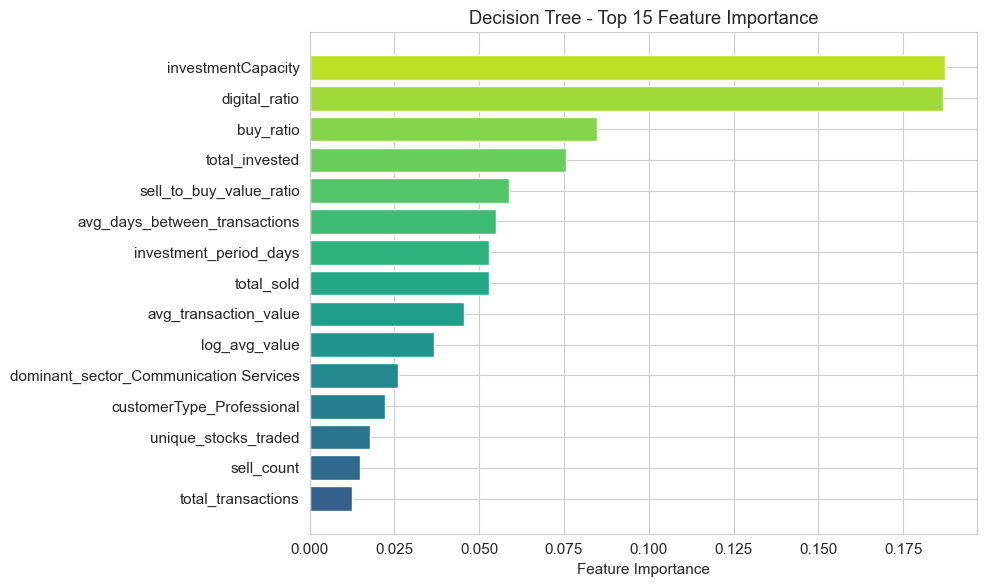


Top 15 Features:
   1. investmentCapacity                       0.1874
   2. digital_ratio                            0.1868
   3. buy_ratio                                0.0847
   4. total_invested                           0.0755
   5. sell_to_buy_value_ratio                  0.0588
   6. avg_days_between_transactions            0.0549
   7. investment_period_days                   0.0528
   8. total_sold                               0.0528
   9. avg_transaction_value                    0.0456
  10. log_avg_value                            0.0366
  11. dominant_sector_Communication Services   0.0259
  12. customerType_Professional                0.0222
  13. unique_stocks_traded                     0.0177
  14. sell_count                               0.0149
  15. total_transactions                       0.0125


In [24]:
# Decision Tree - Feature Importance
plot_feature_importance(dt_best, X_train.columns.tolist(), "Decision Tree")

---
## 4. Model 2: Random Forest

### Justifikasi
Random Forest dipilih sebagai **advanced ensemble** karena:
- Mengurangi overfitting dibanding single Decision Tree melalui bagging
- Robust terhadap outliers dan noise
- Memberikan feature importance yang lebih stabil
- Cocok untuk dataset dengan campuran fitur numerical dan categorical

### Hyperparameter Grid (Reduced)
Fokus pada `n_estimators` (jumlah trees), `max_depth` (kompleksitas), dan `min_samples_leaf` (regularization).

**Total: 12 kombinasi × 5 folds = 60 fits (estimasi 2-4 menit)**

In [25]:
# Random Forest - Hyperparameter Tuning (Fix #1: reduced grid)
print("Random Forest - GridSearchCV (5-fold Stratified CV)")
print("="*60)

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=1)

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV F1-macro: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

Random Forest - GridSearchCV (5-fold Stratified CV)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV F1-macro: 0.4215


In [26]:
# Random Forest - Evaluation
rf_metrics, rf_pred = evaluate_model(
    rf_best, X_train, y_train, X_test, y_test, 
    "Random Forest", label_names
)


  Random Forest - Evaluation Results
  Train Accuracy: 0.7773
  Test Accuracy:  0.4433
  Precision (macro): 0.4237
  Recall (macro):    0.4579
  F1-Score (macro):  0.4315
  [!] Overfitting detected: gap = 0.3340

--- Classification Report ---
              precision    recall  f1-score   support

  Aggressive     0.3378    0.4058    0.3687       308
    Balanced     0.4615    0.5249    0.4912       903
Conservative     0.3766    0.5492    0.4468       386
      Income     0.5190    0.3517    0.4193      1126

    accuracy                         0.4433      2723
   macro avg     0.4237    0.4579    0.4315      2723
weighted avg     0.4593    0.4433    0.4413      2723



  [SAVED] cm_random_forest.png


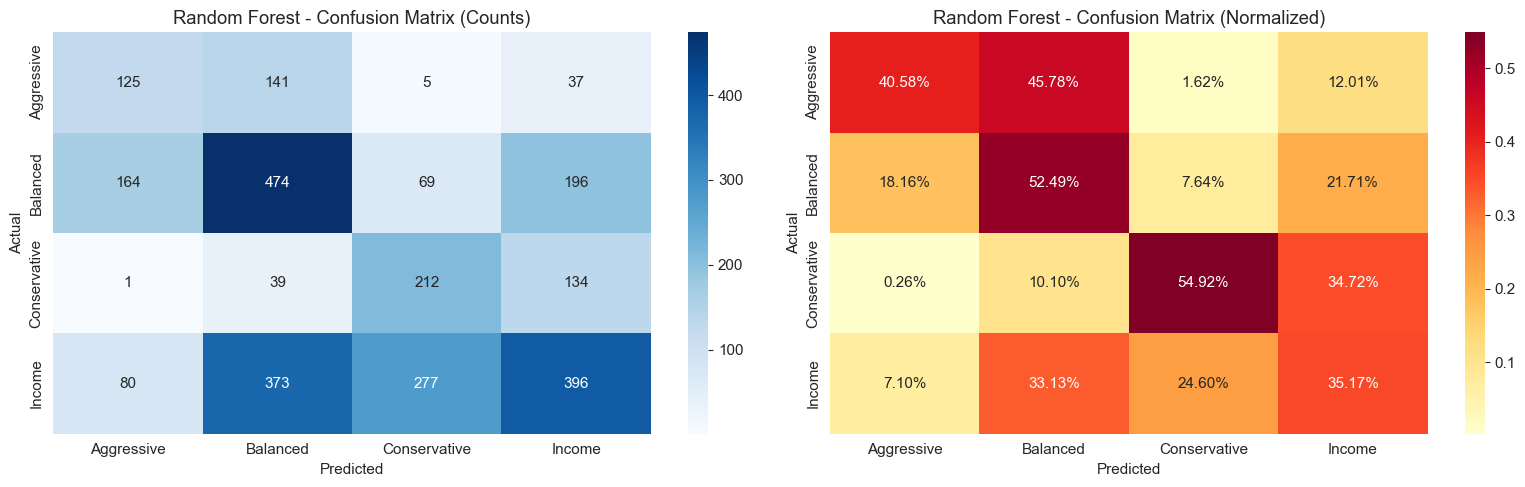

In [27]:
# Random Forest - Confusion Matrix
plot_confusion_matrix(y_test, rf_pred, label_names, "Random Forest")

  [SAVED] feat_imp_random_forest.png


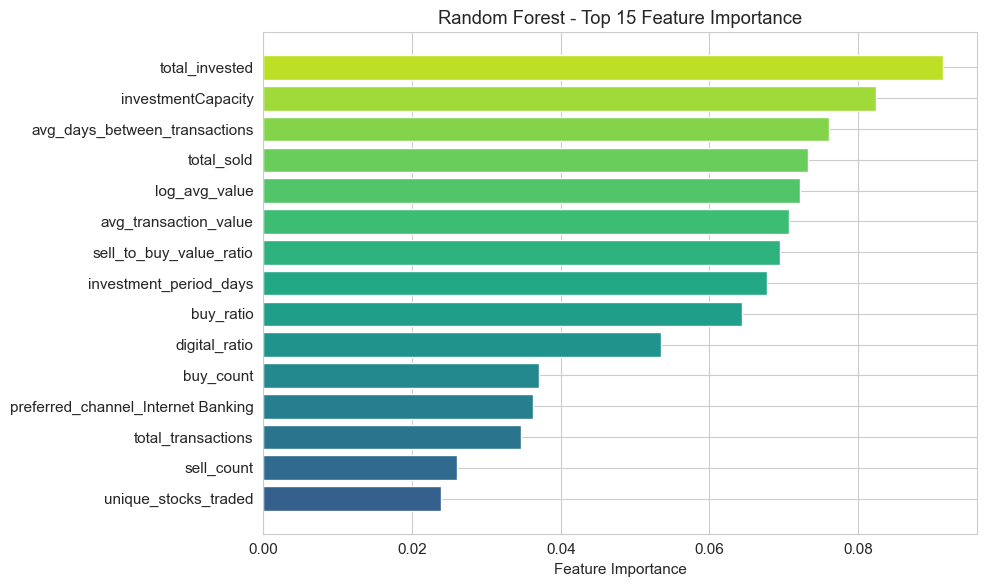


Top 15 Features:
   1. total_invested                           0.0914
   2. investmentCapacity                       0.0824
   3. avg_days_between_transactions            0.0761
   4. total_sold                               0.0733
   5. log_avg_value                            0.0721
   6. avg_transaction_value                    0.0707
   7. sell_to_buy_value_ratio                  0.0695
   8. investment_period_days                   0.0678
   9. buy_ratio                                0.0643
  10. digital_ratio                            0.0534
  11. buy_count                                0.0371
  12. preferred_channel_Internet Banking       0.0362
  13. total_transactions                       0.0346
  14. sell_count                               0.0260
  15. unique_stocks_traded                     0.0239


In [28]:
# Random Forest - Feature Importance
plot_feature_importance(rf_best, X_train.columns.tolist(), "Random Forest")

---
## 5. Model 3: XGBoost

### Justifikasi
XGBoost dipilih sebagai **state-of-the-art** karena:
- Gradient boosting yang sekuensial (memperbaiki error model sebelumnya)
- Regularization built-in (L1, L2) untuk mencegah overfitting
- Handling class imbalance dengan `sample_weight`
- Biasanya memberikan performa terbaik pada tabular data

### Handling Class Imbalance
XGBoost tidak punya parameter `class_weight` seperti sklearn estimators. Sebagai gantinya, kita gunakan `sample_weight` yang dihitung dengan `compute_sample_weight('balanced', y_train)` - secara matematis equivalent dengan class_weight='balanced'.

### Hyperparameter Grid (Reduced)
Fokus pada parameter paling impactful menurut Chen & Guestrin (2016):
- `learning_rate` & `n_estimators` (trade-off shrinkage vs jumlah trees)
- `max_depth` (kompleksitas)
- `subsample` (stochastic regularization)
- `reg_lambda` (L2 regularization)

**Total: 24 kombinasi × 5 folds = 120 fits (estimasi 3-5 menit)**

In [29]:
# XGBoost - Compute sample weights untuk class imbalance
sample_weights = compute_sample_weight('balanced', y_train)

print("Sample weights per class:")
for cls, name in enumerate(label_names):
    mask = y_train == cls
    print(f"  {name}: weight = {sample_weights[mask].mean():.4f}")

Sample weights per class:
  Aggressive: weight = 2.2094
  Balanced: weight = 0.7542
  Conservative: weight = 1.7641
  Income: weight = 0.6044


In [31]:
# XGBoost - Hyperparameter Tuning (Fix #1: reduced + Fix #4: hapus deprecated param)
print("XGBoost - GridSearchCV (5-fold Stratified CV)")
print("="*60)

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'reg_lambda': [1.0, 2.0]
}

# Fix #4: hapus use_label_encoder=False (deprecated parameter)
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=1
)

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Pass sample_weight via fit_params
xgb_grid.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nBest parameters: {xgb_grid.best_params_}")
print(f"Best CV F1-macro: {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_

XGBoost - GridSearchCV (5-fold Stratified CV)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'reg_lambda': 2.0, 'subsample': 1.0}
Best CV F1-macro: 0.4611


In [32]:
# XGBoost - Evaluation
xgb_metrics, xgb_pred = evaluate_model(
    xgb_best, X_train, y_train, X_test, y_test, 
    "XGBoost", label_names
)


  XGBoost - Evaluation Results
  Train Accuracy: 0.4665
  Test Accuracy:  0.4076
  Precision (macro): 0.4133
  Recall (macro):    0.4940
  F1-Score (macro):  0.4098
  [!] Overfitting detected: gap = 0.0588

--- Classification Report ---
              precision    recall  f1-score   support

  Aggressive     0.3135    0.5649    0.4032       308
    Balanced     0.4512    0.4507    0.4510       903
Conservative     0.3529    0.7461    0.4792       386
      Income     0.5356    0.2140    0.3058      1126

    accuracy                         0.4076      2723
   macro avg     0.4133    0.4940    0.4098      2723
weighted avg     0.4566    0.4076    0.3896      2723



  [SAVED] cm_xgboost.png


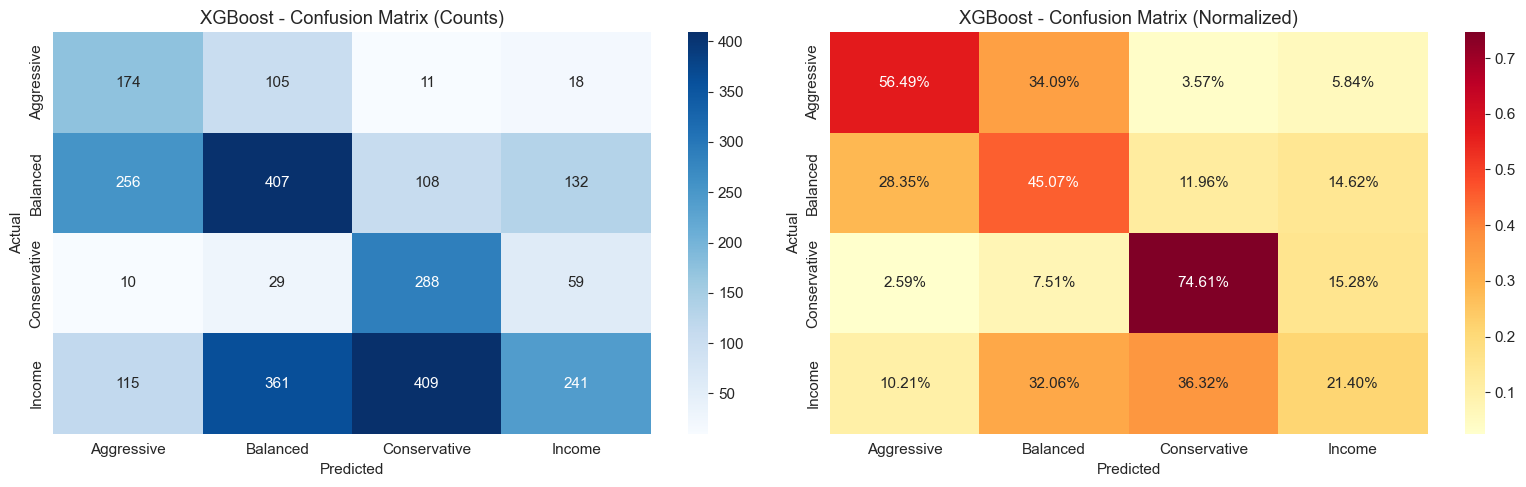

In [33]:
# XGBoost - Confusion Matrix
plot_confusion_matrix(y_test, xgb_pred, label_names, "XGBoost")

  [SAVED] feat_imp_xgboost.png


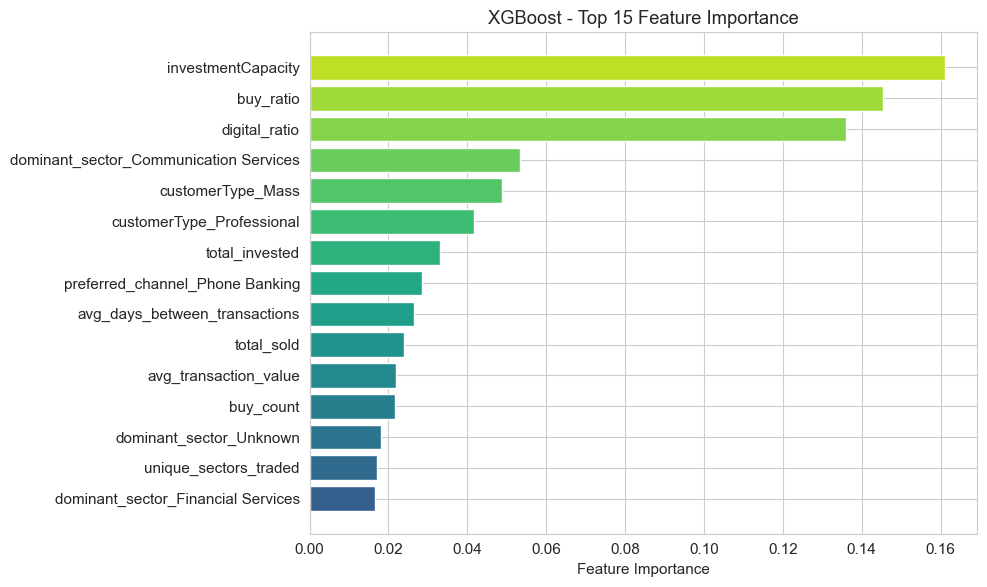


Top 15 Features:
   1. investmentCapacity                       0.1612
   2. buy_ratio                                0.1454
   3. digital_ratio                            0.1361
   4. dominant_sector_Communication Services   0.0533
   5. customerType_Mass                        0.0489
   6. customerType_Professional                0.0417
   7. total_invested                           0.0330
   8. preferred_channel_Phone Banking          0.0284
   9. avg_days_between_transactions            0.0265
  10. total_sold                               0.0239
  11. avg_transaction_value                    0.0220
  12. buy_count                                0.0218
  13. dominant_sector_Unknown                  0.0180
  14. unique_sectors_traded                    0.0170
  15. dominant_sector_Financial Services       0.0167


In [34]:
# XGBoost - Feature Importance
plot_feature_importance(xgb_best, X_train.columns.tolist(), "XGBoost")

---
## 6. Perbandingan Model

Membandingkan ketiga model secara side-by-side untuk menentukan model terbaik berdasarkan F1-macro (primary metric untuk imbalanced multi-class).

In [35]:
# Comparison table
all_metrics = [dt_metrics, rf_metrics, xgb_metrics]
comparison_df = pd.DataFrame(all_metrics).set_index('Model')

print("="*70)
print("  MODEL COMPARISON - All Metrics")
print("="*70)
print(comparison_df.round(4).to_string())

# Highlight best
print(f"\n{'='*70}")
best_model_name = comparison_df['F1-Score (macro)'].idxmax()
best_f1 = comparison_df['F1-Score (macro)'].max()
print(f"  [BEST] Best Model: {best_model_name} (F1-macro = {best_f1:.4f})")
print(f"{'='*70}")

# Fix #6: Save comparison sebagai CSV untuk laporan
comparison_path = REPORT_DIR / 'model_comparison.csv'
comparison_df.round(4).to_csv(comparison_path)
print(f"\n[SAVED] Comparison table: {comparison_path}")

  MODEL COMPARISON - All Metrics
               Train Accuracy  Test Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Model                                                                                            
Decision Tree          0.5064         0.3849             0.3834          0.4521            0.3864
Random Forest          0.7773         0.4433             0.4237          0.4579            0.4315
XGBoost                0.4665         0.4076             0.4133          0.4940            0.4098

  [BEST] Best Model: Random Forest (F1-macro = 0.4315)

[SAVED] Comparison table: C:\All Projects\Transparent Investment Intentions Dashboard\reports\model_comparison.csv


[SAVED] model_comparison.png


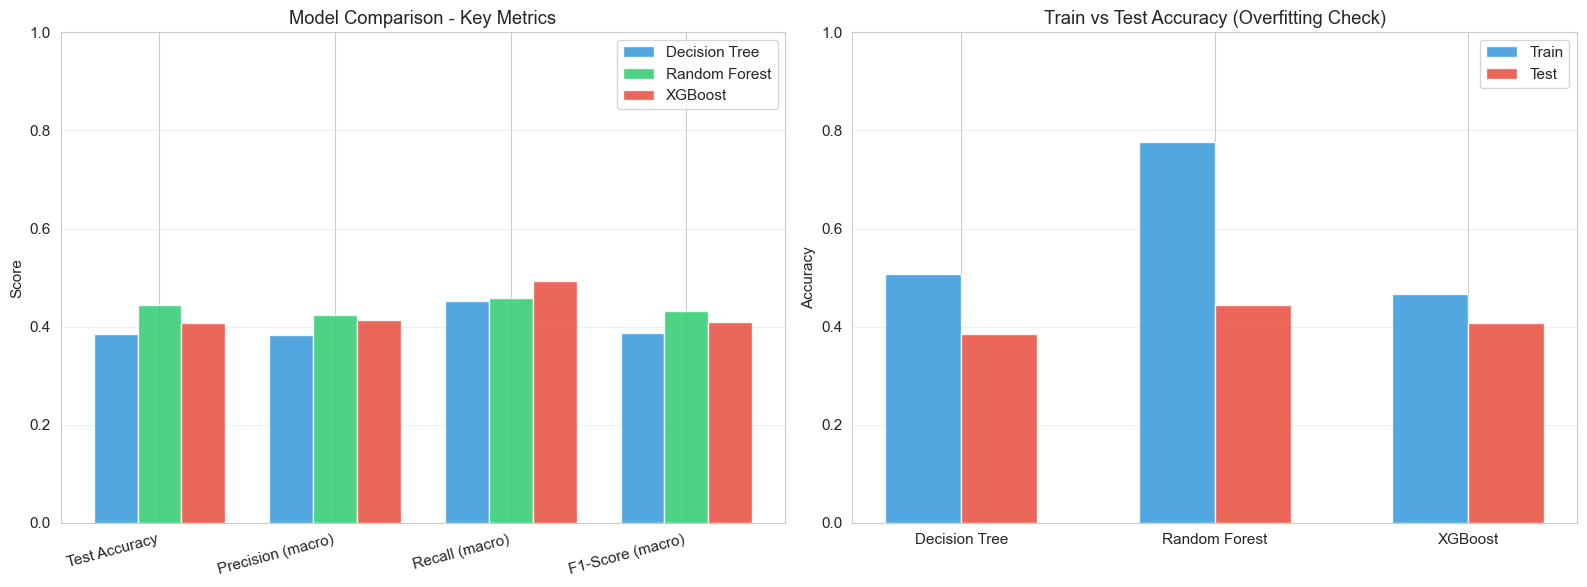

In [36]:
# Visualization - Model Comparison
metrics_to_plot = ['Test Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
x = np.arange(len(metrics_to_plot))
width = 0.25
models = comparison_df.index.tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model, color) in enumerate(zip(models, colors)):
    values = [comparison_df.loc[model, m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=model, color=color, alpha=0.85)

axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison - Key Metrics')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Train vs Test accuracy (overfitting check)
train_acc = [comparison_df.loc[m, 'Train Accuracy'] for m in models]
test_acc = [comparison_df.loc[m, 'Test Accuracy'] for m in models]

x2 = np.arange(len(models))
axes[1].bar(x2 - 0.15, train_acc, 0.3, label='Train', color='#3498db', alpha=0.85)
axes[1].bar(x2 + 0.15, test_acc, 0.3, label='Test', color='#e74c3c', alpha=0.85)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy (Overfitting Check)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Fix #7: Save visualisasi
fig_path = FIG_DIR / 'model_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"[SAVED] {fig_path.name}")
plt.show()

---
## 7. Save Best Model & Metadata

Simpan ketiga model + best model + metadata lengkap untuk digunakan di tahap XAI (notebook 04) dan deployment dashboard.

In [37]:
# Save semua model
models_dict = {
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}

best_model = models_dict[best_model_name]

# Save best model dengan nama khusus
best_path = MODEL_DIR / 'best_model.pkl'
joblib.dump(best_model, best_path)
print(f"[OK] Best model ({best_model_name}) saved to: {best_path}")

# Save semua model individual
for name, model in models_dict.items():
    safe_name = name.lower().replace(' ', '_')
    path = MODEL_DIR / f'{safe_name}.pkl'
    joblib.dump(model, path)
    print(f"[OK] {name} saved to: {path}")

# Save metadata komprehensif
metadata = {
    'best_model': best_model_name,
    'label_names': label_names,
    'label_encoding': {name: i for i, name in enumerate(label_names)},
    'feature_names': X_train.columns.tolist(),
    'n_features': X_train.shape[1],
    'n_train': len(X_train),
    'n_test': len(X_test),
    'metrics_all': all_metrics,
    'best_params': {
        'decision_tree': {k: str(v) for k, v in dt_grid.best_params_.items()},
        'random_forest': {k: str(v) for k, v in rf_grid.best_params_.items()},
        'xgboost': {k: str(v) for k, v in xgb_grid.best_params_.items()}
    },
    'cv_strategy': 'StratifiedKFold(n_splits=5, shuffle=True, random_state=42)',
    'scoring_metric': 'f1_macro',
    'class_imbalance_handling': {
        'decision_tree': "class_weight='balanced'",
        'random_forest': "class_weight='balanced'",
        'xgboost': "sample_weight via compute_sample_weight('balanced', y_train)"
    }
}

meta_path = MODEL_DIR / 'model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"\n[OK] Metadata saved to: {meta_path}")

[OK] Best model (Random Forest) saved to: C:\All Projects\Transparent Investment Intentions Dashboard\models\best_model.pkl
[OK] Decision Tree saved to: C:\All Projects\Transparent Investment Intentions Dashboard\models\decision_tree.pkl
[OK] Random Forest saved to: C:\All Projects\Transparent Investment Intentions Dashboard\models\random_forest.pkl
[OK] XGBoost saved to: C:\All Projects\Transparent Investment Intentions Dashboard\models\xgboost.pkl

[OK] Metadata saved to: C:\All Projects\Transparent Investment Intentions Dashboard\models\model_metadata.json


---
## 8. Cross-Validation Stability Check

Verifikasi stabilitas performa model terbaik dengan 10-fold cross-validation. Std rendah menunjukkan model konsisten across folds (low variance).

10-Fold Stratified Cross-Validation - Random Forest
  Fold scores: [0.4246 0.4172 0.4238 0.4362 0.4195 0.4304 0.4311 0.4142 0.4193 0.4056]
  Mean F1-macro: 0.4222
  Std F1-macro:  0.0086
  Min: 0.4056 | Max: 0.4362
  [OK] Model stabil (std < 0.02)

[SAVED] cv_stability.png


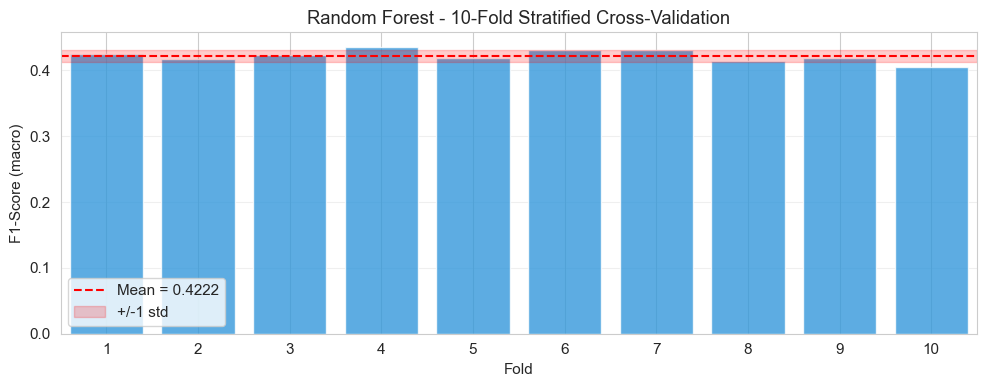

In [38]:
# 10-fold Cross-Validation pada model terbaik (Fix #5: StratifiedKFold dengan seed)
print(f"10-Fold Stratified Cross-Validation - {best_model_name}")
print("="*60)

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, 
                             cv=skf_10, scoring='f1_macro', n_jobs=-1)

print(f"  Fold scores: {cv_scores.round(4)}")
print(f"  Mean F1-macro: {cv_scores.mean():.4f}")
print(f"  Std F1-macro:  {cv_scores.std():.4f}")
print(f"  Min: {cv_scores.min():.4f} | Max: {cv_scores.max():.4f}")

if cv_scores.std() < 0.02:
    print(f"  [OK] Model stabil (std < 0.02)")
else:
    print(f"  [!] Variabilitas cukup tinggi (std >= 0.02)")

# Plot CV scores
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 11), cv_scores, color='#3498db', alpha=0.8)
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between([0.5, 10.5], 
                cv_scores.mean() - cv_scores.std(), 
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red', label=f'+/-1 std')
ax.set_xlabel('Fold')
ax.set_ylabel('F1-Score (macro)')
ax.set_title(f'{best_model_name} - 10-Fold Stratified Cross-Validation')
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(0.5, 10.5)
plt.tight_layout()

# Save plot
cv_fig_path = FIG_DIR / 'cv_stability.png'
plt.savefig(cv_fig_path, dpi=150, bbox_inches='tight')
print(f"\n[SAVED] {cv_fig_path.name}")
plt.show()

---
## 9. Kesimpulan & Next Steps

### Ringkasan Modeling

Tiga model klasifikasi telah dilatih dan dievaluasi untuk memprediksi **risk level** investor berdasarkan 33 fitur perilaku transaksi saham.

| Aspek | Detail |
|-------|--------|
| **Dataset** | 10.888 train / 2.723 test (stratified 80/20) |
| **Target** | 4 kelas: Aggressive, Balanced, Conservative, Income |
| **Models** | Decision Tree (baseline), Random Forest, XGBoost |
| **Evaluation** | F1-macro sebagai primary metric (handles class imbalance) |
| **CV Strategy** | StratifiedKFold(n_splits=5, shuffle=True, random_state=42) |
| **Class Imbalance** | `class_weight='balanced'` (DT/RF) dan `sample_weight` (XGB) |

### Output Tersimpan

Setelah notebook ini dijalankan, output yang tersedia:

**Models (`models/`):**
- `best_model.pkl` - model terbaik untuk deployment
- `decision_tree.pkl`, `random_forest.pkl`, `xgboost.pkl` - semua model
- `label_encoder.pkl` - encoder untuk transformasi label
- `model_metadata.json` - metadata lengkap (params, metrics, dll)

**Reports (`reports/`):**
- `model_comparison.csv` - tabel perbandingan untuk laporan
- `figures/modeling/cm_*.png` - confusion matrices
- `figures/modeling/feat_imp_*.png` - feature importance plots
- `figures/modeling/model_comparison.png` - bar chart perbandingan
- `figures/modeling/cv_stability.png` - CV stability check

### Next Steps

**`04_explainability.ipynb`** - Explainable AI (XAI):
- SHAP values untuk global & local interpretability
- Feature contribution analysis per prediction
- Knowledge-Based System rules integration